In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/manurajgoel/Desktop/MLPRACTICAL/CUSTOMER CHURN MODEL/RawData_Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# To know the number of (row,columns)
df.shape

(7043, 21)

In [5]:
# From this we get the exact column names for further use
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [6]:
# Shows the data type for each column
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
# Check the descriptive statistics of numeric columns only
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


* SeniorCitizen is a categorical variable (1(Yes)/0(No)), so statistics like 25%, 50%, and 75% are not meaningful for understanding its distribution.
* 75% of customers have been with the company for less than 55 months.
* The average monthly charge is USD 64.76, while 25% of cutomers pay nore than USD 89.85 per month.

* Tenure ranges from 0 to 72 months (avg tenure = 32.37 months)
* MonthlyCharges ranges from 18.25 to 118.75 (avg monthly charges = USD 64.7)

* TotalCharges does not appear here because pandas currently sees it as text/object, not numeric.

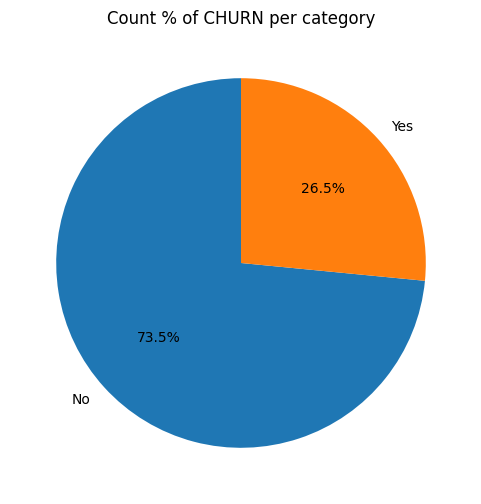

In [8]:
# Plotting CHURN COUNT on bar graph
# it is drawn to check how balanced our target variable(churn distribution) is

plt.figure(figsize=(6,6))

df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

plt.ylabel("")
plt.title("Count % of CHURN per category")
plt.show()

In [9]:
11# calculating Churn percentages
df['Churn'].value_counts()*100/len(df['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

* This means about 73.46% of customers did not churn and 26.54% churned.
* This 73:27 imbalance means if a model blindly predicts "No churn" for every single customer, it gets 73% accuracy but catches zero churners.
* That's why accuracy alone is meaningless here.
* In the model building, we will use SMOTEENN and check recall/F1 instead.

In [10]:
# calculating Churn values
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

* Data is highly imbalanced, ratio = 73:27

In [11]:
# Concise Summary of the dataframe, as we have too many columns, we are using the verbose = True mode
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

In [12]:
# Creating a fully independent copy of the original dataset 
df_copy = df.copy()


Without .copy(), telco_data = telco_base_data makes both variables refer to the same data. So, changing telco_data also changes telco_base_data, which can cause unexpected bugs and warnings like SettingWithCopyWarning.


In [13]:
# Changing datatype of TotalCharges (from string to float)

df_copy.TotalCharges = pd.to_numeric(df_copy.TotalCharges, errors='coerce')
df_copy.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df_copy[df_copy['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [15]:
# Treating Missing Values of TotalCharges
df_copy.dropna(how = 'any', inplace=True)

* Since the number of missing values is very small as compared to the total dataset,
* We can safely remove these rows without significantly affecting the analysis.

In [16]:
# Get the max tenure
print(df_copy['tenure'].max())

72


In [17]:
print(df[['MonthlyCharges', 'TotalCharges']].dtypes)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

MonthlyCharges    float64
TotalCharges       object
dtype: object


In [18]:
# Detect Outliers using IQR

for col in ['MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} Outliers: {len(outliers)}")

MonthlyCharges Outliers: 0
TotalCharges Outliers: 0


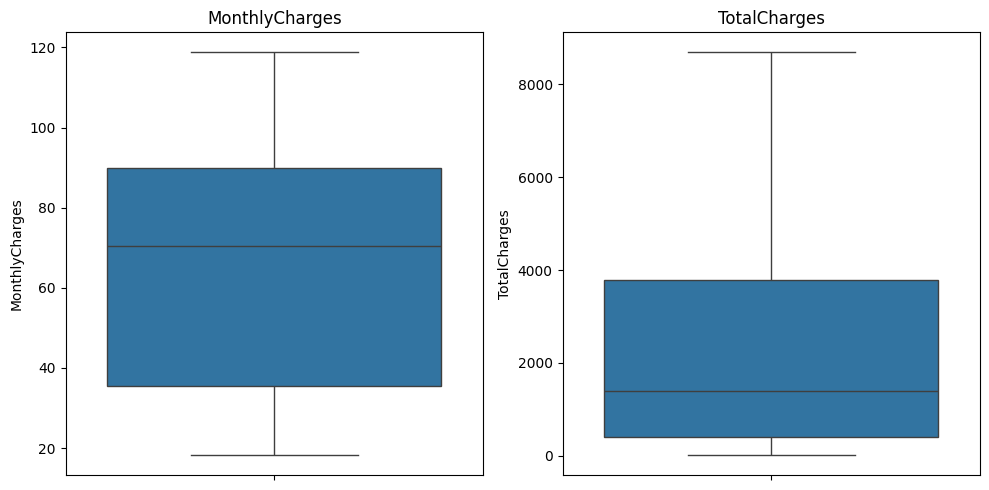

In [19]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['MonthlyCharges'])
plt.title("MonthlyCharges")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['TotalCharges'])
plt.title("TotalCharges")

plt.tight_layout()
plt.show()

OUTLIER DETECTION : 

* Outlier detection was performed using the IQR method.
* Only MonthlyCharges and TotalCharges were analyzed, as they are the only continuous numerical features.
* Result: No outliers were detected in either MonthlyCharges or TotalCharges.
* This is expected because telecom pricing follows predefined plans and pricing tiers, keeping these values within a reasonable range.
* Decision: No outlier removal or capping was required.

# Feature Engineering

TENURE GROUPING : 

* Group customers based on their tenure (how long they have stayed).
* Example: 1-12 months, 13-24 months, 25-36 months, and so on.

In [20]:
# Group the tenure in bins of 12 months


# create labels for each tenure group (1-12,, 13-24,...))
labels = [f'{i} - {i+11}' for i in range(1, 72, 12)]

# new column
df_copy['tenure_group'] = pd.cut(
    df_copy['tenure'],
    bins=range(1, 80, 12),
    right=False,
    labels=labels
)

# right = False -> Means the left value is included and the right value is excluded
# labels = labels ->     Replaces the bin ranges with readable names

In [21]:
df_copy['tenure_group'].value_counts()

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64

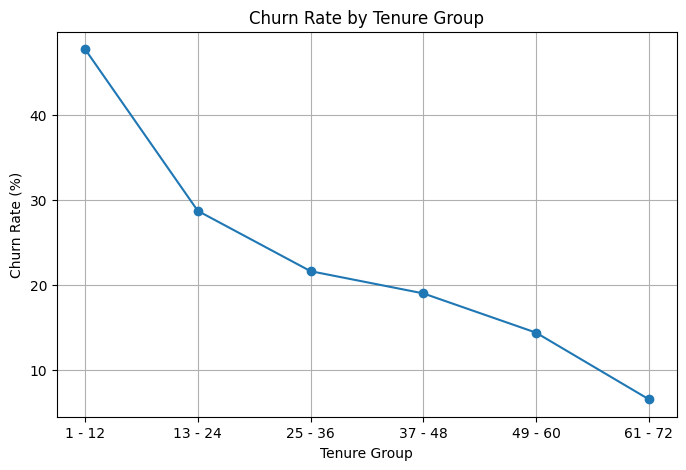

In [22]:
# Churn Rate (%) by Tenure Group

churn_rate = (
    df_copy.groupby('tenure_group', observed=False)['Churn']
    .value_counts(normalize=True)
    .unstack() * 100
)

plt.figure(figsize=(8, 5))
plt.plot(churn_rate.index, churn_rate['Yes'], marker='o')

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.grid(True)
plt.show()



# Dropping Columns

In [23]:
# dropping column customerID and tenure
df_copy.drop(columns= ['customerID','tenure'], axis=1, inplace=True)
df_copy.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


Dropping Unnecessary Columns

Before training the machine learning model, some columns are removed because they do not contribute to prediction.

- **customerID**
  - It is a unique identifier for each customer.
  - It does not contain any predictive information and can introduce unnecessary noise.

- **tenure**
  - The original `tenure` column was used to create the new `tenure_group` feature.
  - Since `tenure_group` captures the customer's tenure in meaningful categories, keeping both columns would introduce redundant information.
  - Therefore, the original `tenure` column is dropped to avoid duplication.

# Univariate Analysis

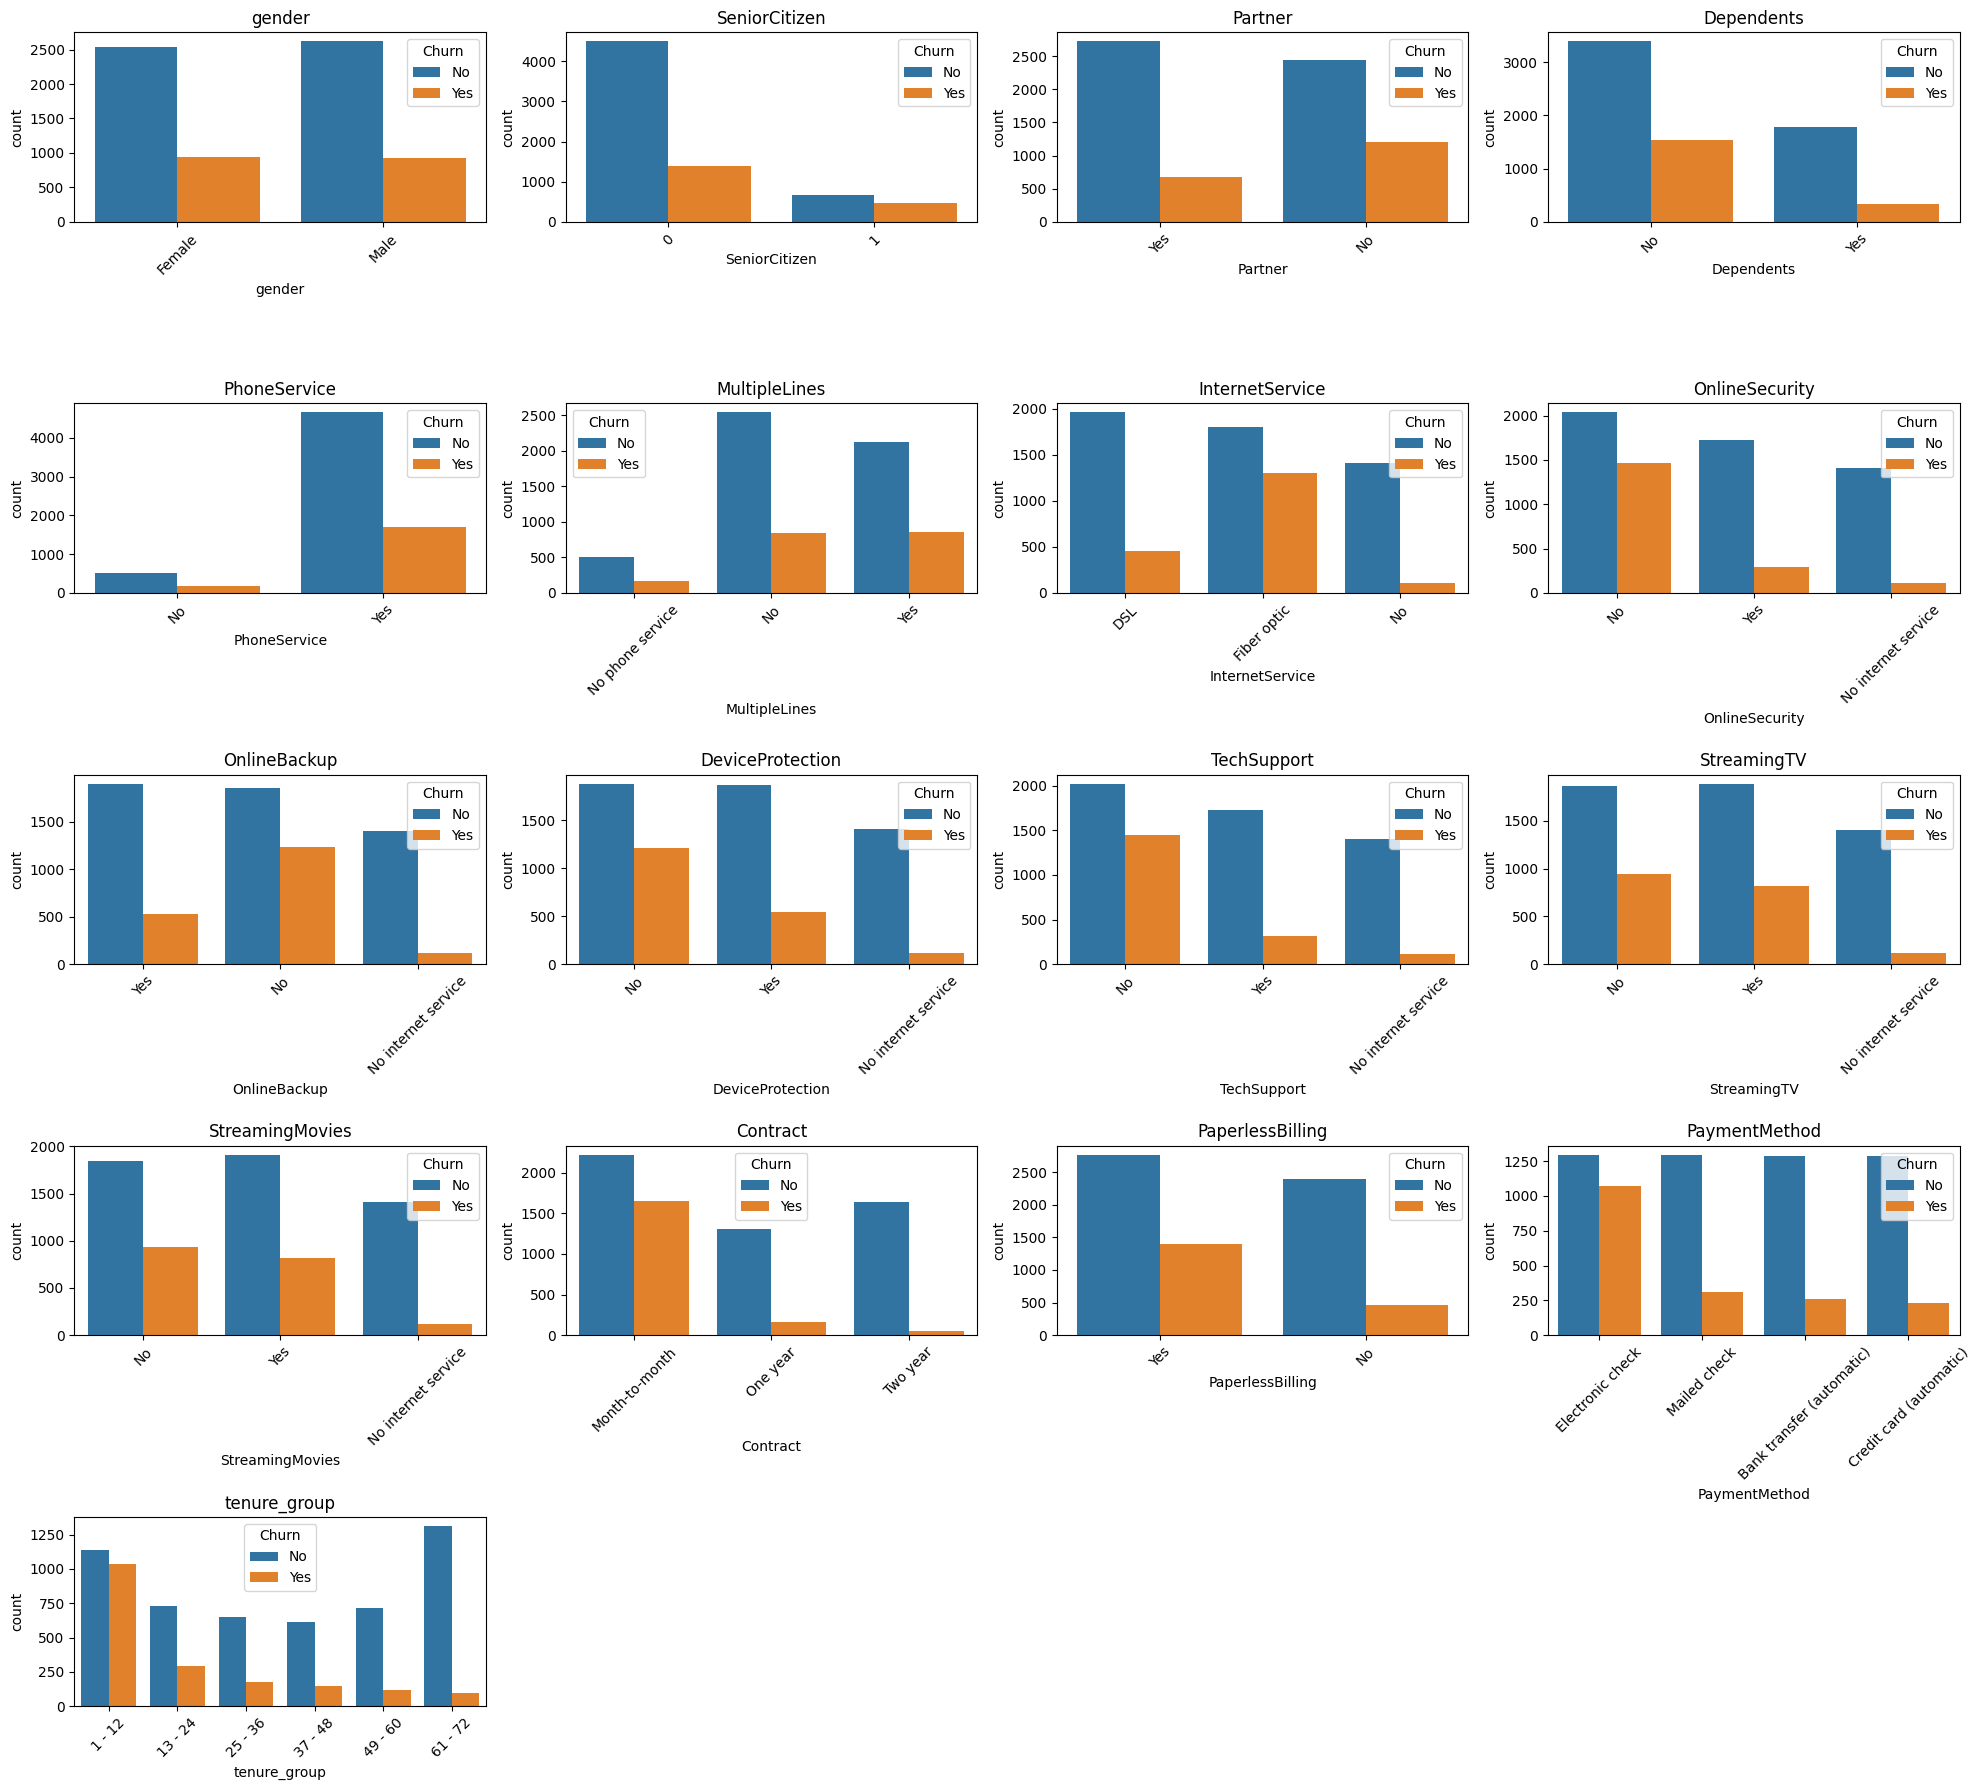

In [24]:
# Categorical Feature Analysis

categorical_cols = df_copy.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges']).columns

plt.figure(figsize=(20, 18))

for i, predictor in enumerate(categorical_cols):
    plt.subplot(5, 4, i + 1)
    sns.countplot(data=df_copy, x=predictor, hue='Churn')
    plt.title(predictor)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Excluded numerical(Total and Monthly charges) features and the target variable(Churn) from countplots.
# (Numerical columns are excluded because count plots are meant for categorical data. Continuous numerical 
# features are better visualized using histograms or box plots.)
# enumerate() provides both the index (i) and the column name (predictor) in each loop.



## Insights from Univariate Analysis

**Contract type is the strongest churn driver**
- Month-to-month customers churn at 42.7% compared to only 2.8% for two-year contracts. With the highest correlation to churn (+0.40), lack of long term commitment is a major risk factor.

**New customers are the most vulnerable**
- Nearly 48% of customers leave within their first year, while churn falls to just 6.6% after 5–6 years. The first year is the most critical period for building loyalty and trust.

**Fiber optic customers are at highest risk**
- Fiber optic users have the highest churn rate (41.9%), despite being premium customers. This suggests that customer expectations may not be matching the value received.

**No security or support = customers feel exposed**
- Customers without Online Security or Tech Support churn at around 42% each, while those with these services churn at only 14–15%. These features appear to increase customer trust and dependence on the service.


**Payment method reflects customer commitment**
- Electronic check(Manually paying customers) users churn at 45.3%, nearly 3x more times the rate of customers using automatic payments (15–16%). Customers with automated payments are generally more likely to stay.

**Family = loyalty**
* Customers with a partner churn at 19.7% vs 33% for singles. With dependents it's 15.5% vs 31.3%. Family-anchored customers have more to lose from switching — shared plans, multiple lines, bundled services. Solo customers are the most price-sensitive and easiest to poach.

**Family customers are more loyal**
- Customers with partners churn at 19.7% compared to 33% for customers without partners. Similarly, customers with dependents churn at 15.5% versus 31.3% for those without dependents. This suggests that customers with families are more loyal and less likely to switch providers.

**Gender, phone service, and streaming are complete noise**
* Gender shows 0.8% difference in churn rate. Phone service shows 1.7%. Streaming TV/Movies show similar churn whether subscribed or not. These features add no predictive value and should likely be dropped or deprioritized in your model.


**The high-risk customer has a clear profile**
* Customers with month-to-month contracts + fiber optic service + electronic check payments + no security/support add-ons + and tenure under 12 months are the most likely to churn and should be the primary focus of retention efforts. A customer matching all five of these is almost certain to churn

# Encoding

In [25]:
# Convert the target variable 'Churn' in a binary numeric variable i.e. Yes=1 ; No = 0

df_copy['Churn'] = np.where(df_copy.Churn == 'Yes',1,0)

# np.where(condition, value_if_true, value_if_false)

In [26]:
df_copy.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [27]:
# ONE-HOT ENCODING

df_copy_dummies = pd.get_dummies(df_copy, drop_first=True)
df_copy_dummies.head()

# drop_first=True removes one dummy column from each categorical feature to 
# avoid the dummy variable trap and redundant information.

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,False,True,False,False,True,False,...,False,True,False,True,False,False,False,False,False,False
1,0,56.95,1889.50,0,True,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False
2,0,53.85,108.15,1,True,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False
3,0,42.30,1840.75,0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,False,False,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False


If we assign Month-to-month = 1, One year = 2, and Two year = 3, the model may think Two year (3) is greater than or has a stronger effect than Month-to-month (1). This introduces a false numerical relationship and can influence the model’s predictions incorrectly. One-hot encoding avoids this by treating each contract type as an independent category using separate 0/1 columns.

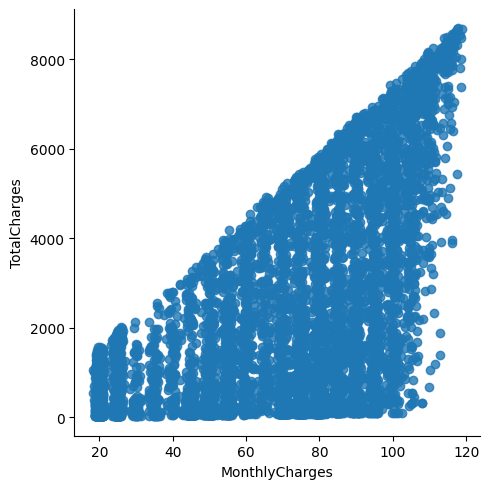

In [28]:
# Relation between Monthly Charges and Total Charges
sns.lmplot(data=df_copy_dummies, x='MonthlyCharges', y='TotalCharges', fit_reg=False)

* Total Charges increase as Monthly Charges increase - as expected.
* Customers paying more per month accumulate higher total charges
* But it's not a perfect line because TotalCharges also depends on tenure.

Text(0.5, 1.0, 'Monthly charges by churn')

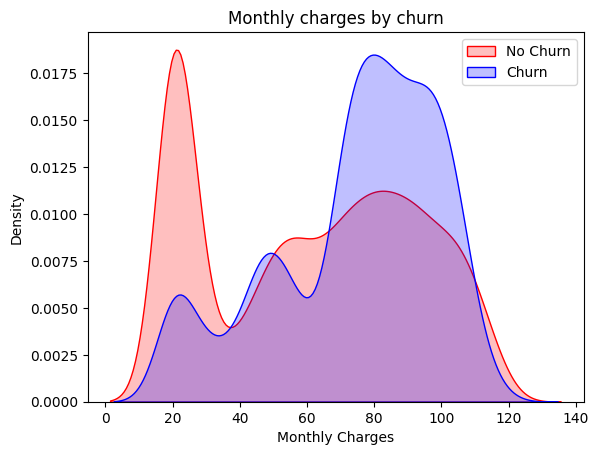

In [29]:
Mth = sns.kdeplot(df_copy_dummies.MonthlyCharges[(df_copy_dummies["Churn"] == 0) ],
                color="Red", fill = True)
Mth = sns.kdeplot(df_copy_dummies.MonthlyCharges[(df_copy_dummies["Churn"] == 1) ],
                ax =Mth, color="Blue", fill = True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

* Churn is high when Monthly Charges ar high
* The blue (churn) curve peaks at HIGHER monthly charges. The red (no churn) curve peaks at LOWER charges
* Conclusion: higher monthly bill → higher churn probability
* Makes business sense expensive customers feel it's not worth it.

Text(0.5, 1.0, 'Total charges by churn')

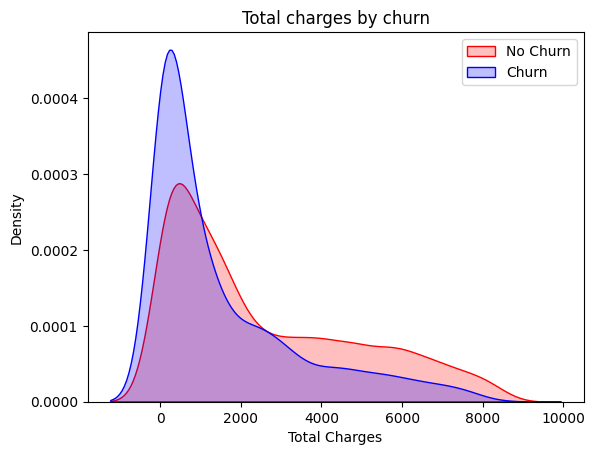

In [30]:
Tot = sns.kdeplot(df_copy_dummies.TotalCharges[(df_copy_dummies["Churn"] == 0) ],
                color="Red", fill = True)
Tot = sns.kdeplot(df_copy_dummies.TotalCharges[(df_copy_dummies["Churn"] == 1) ],
                ax =Tot, color="Blue", fill = True)
Tot.legend(["No Churn","Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total charges by churn')

## Surprising insight as "Higher Churn at lower Total Charges"

* TotalCharges = MonthlyCharges × tenure. Churners have low tenure (they leave early), so even with high monthly charges, their total is low.
* The full picture: high monthly charge + low tenure → low total charges + high churn.
* All three variables are linked you need to look at them together, not in isolation.

* Long-tenure customers are more loyal, so they are less likely to churn despite having higher total bills.
* Conclusion: TotalCharges should be interpreted together with Tenure, as it reflects both the monthly bill and the length of the customer relationship.

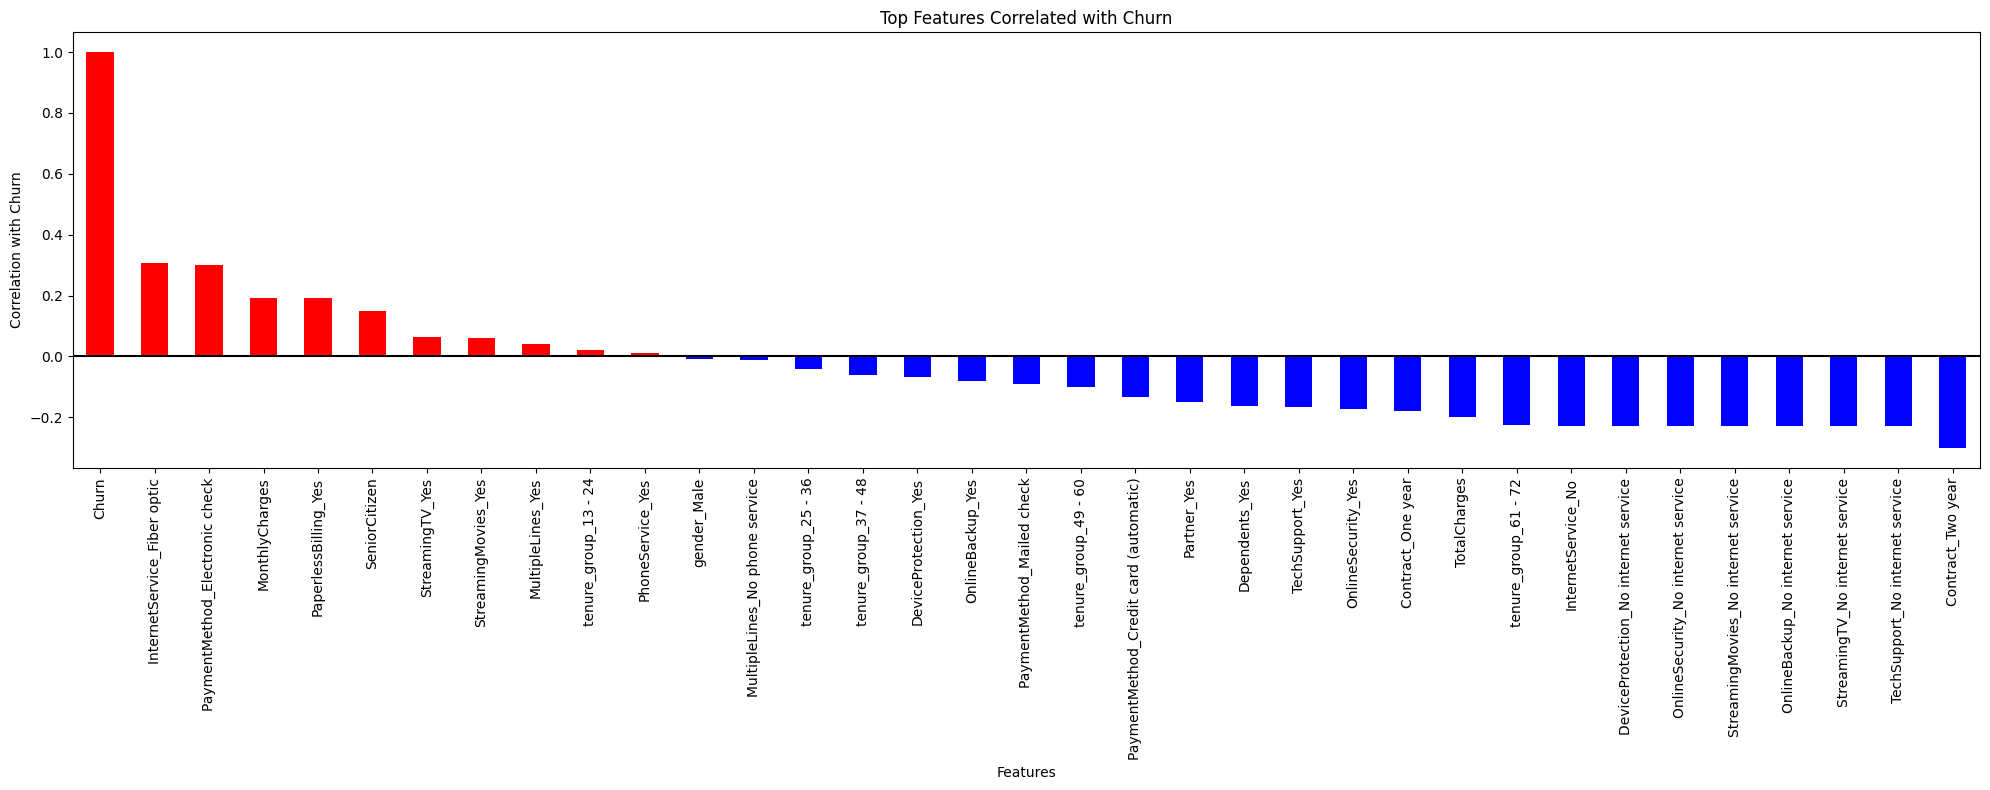

In [31]:
# Build a corelation of all predictors with 'Churn'

corr = df_copy_dummies.corr()['Churn'].sort_values(ascending=False)

colors = ['red' if x > 0 else 'blue' for x in corr]

plt.figure(figsize=(20, 8))
corr.plot(kind='bar', color=colors)

plt.axhline(y=0, color='black')
plt.title("Top Features Correlated with Churn")
plt.xlabel("Features")
plt.ylabel("Correlation with Churn")

plt.tight_layout()
plt.show()

## Derived Insight:

1. Contract type has the biggest impact on churn. Month-to-month customers churn the most, while two-year contract customers are the most loyal.
2. Lack of Online Security and Tech Support is linked to higher churn. Customers without these services are more likely to leave.
3. New customers churn more often. Churn is highest during the first year, while customers with 5+ years of tenure tend to stay.
4. Fiber Optic users show higher churn
5. Whereas Gender, Phone Service, and Multiple Lines have little/no impact on churn.


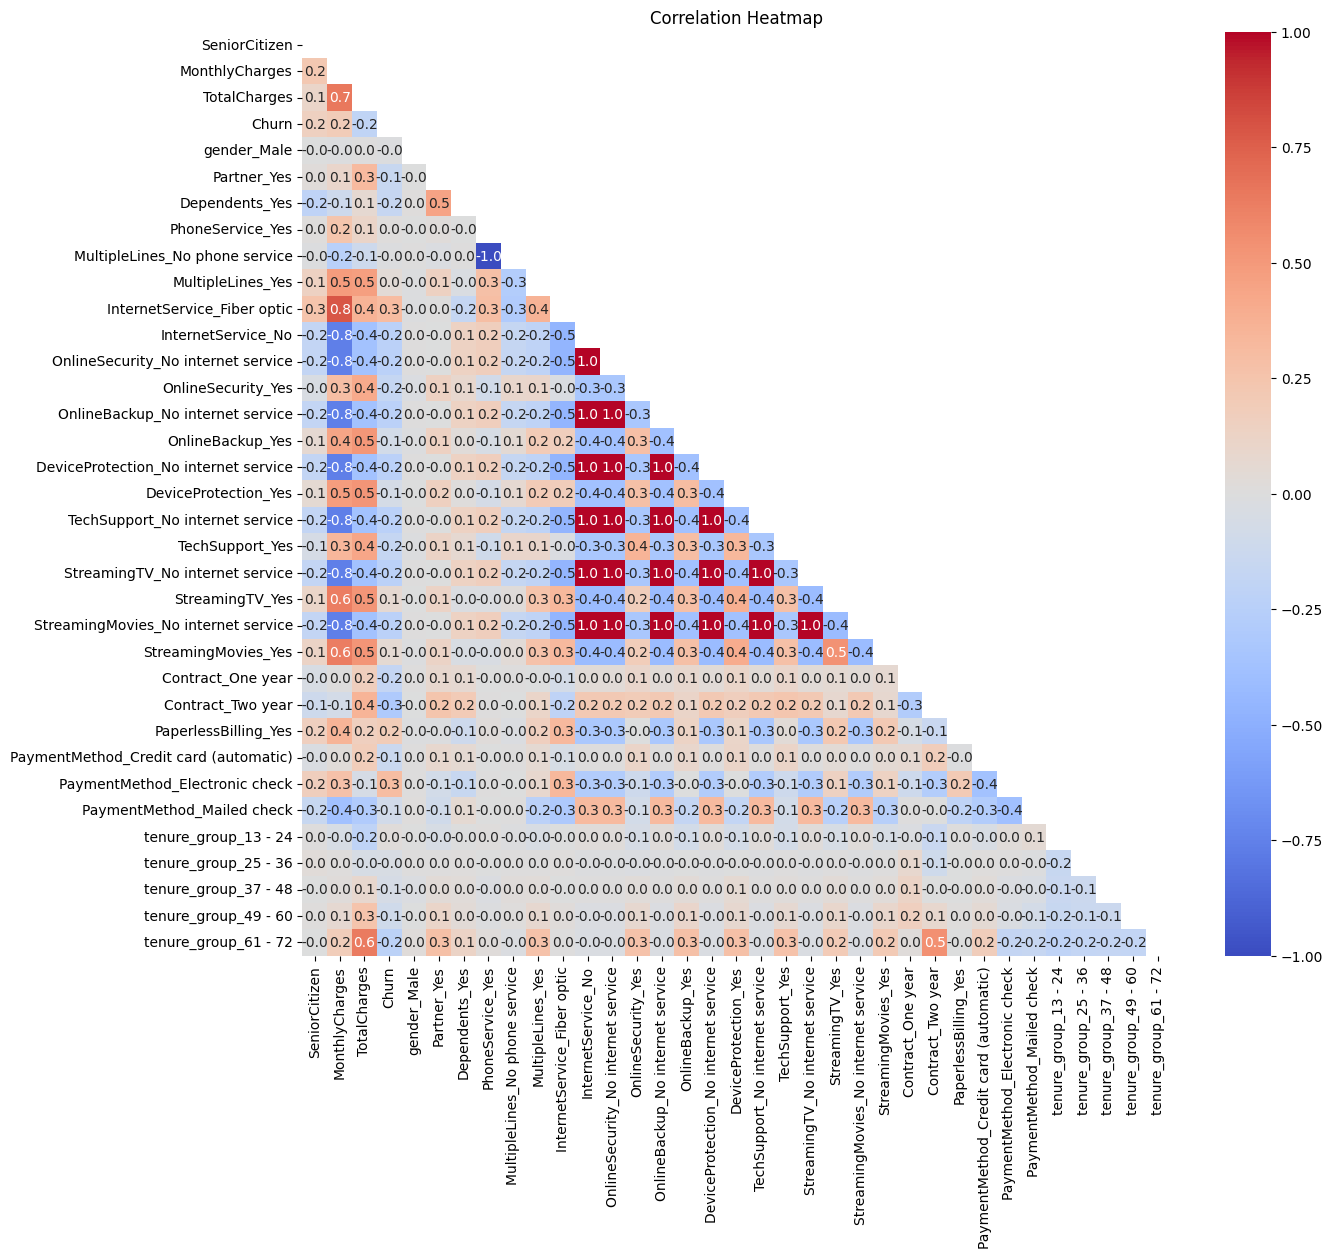

In [32]:
# PLotting a HEATMAP

plt.figure(figsize=(14, 12))

mask = np.triu(df_copy_dummies.corr())

sns.heatmap(
    df_copy_dummies.corr(),
    annot=True,
    mask=mask,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Bivariate Analysis

<Figure size 1000x600 with 0 Axes>

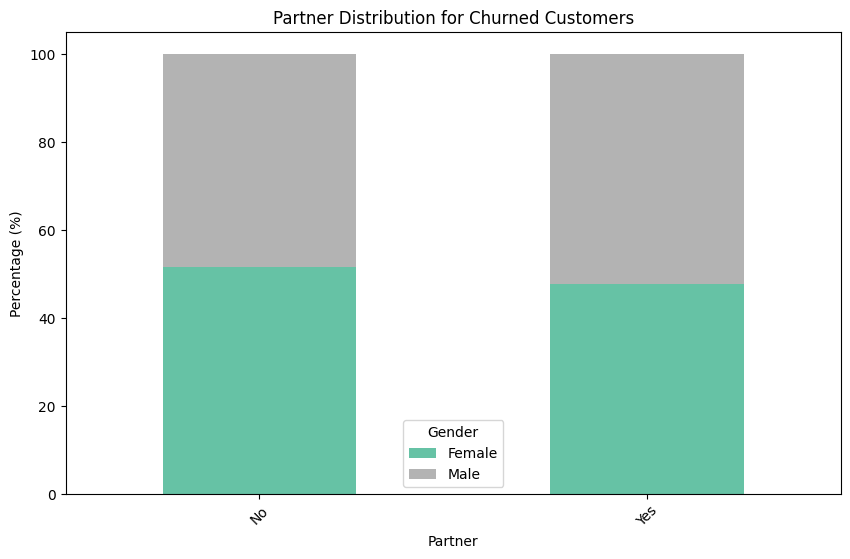

<Figure size 1000x600 with 0 Axes>

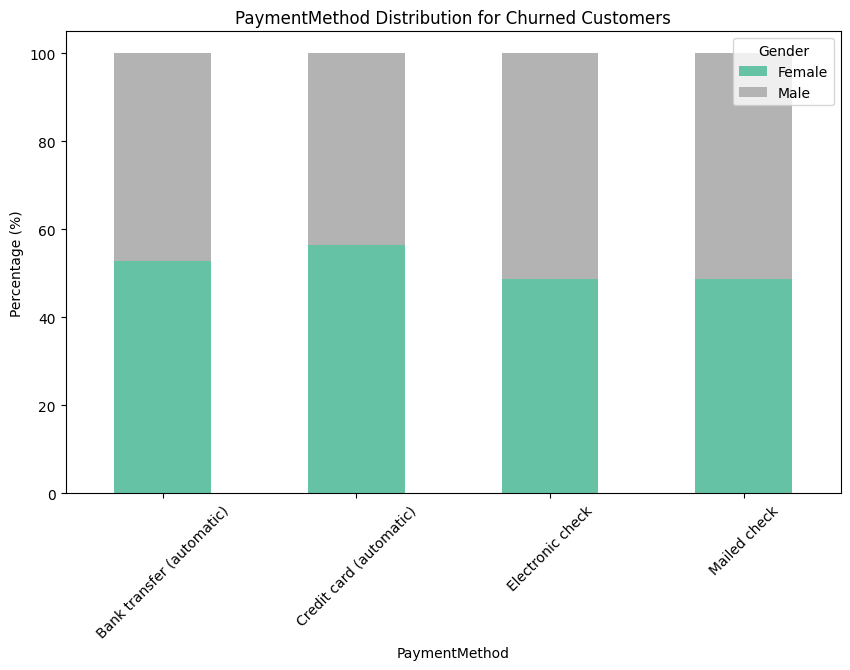

<Figure size 1000x600 with 0 Axes>

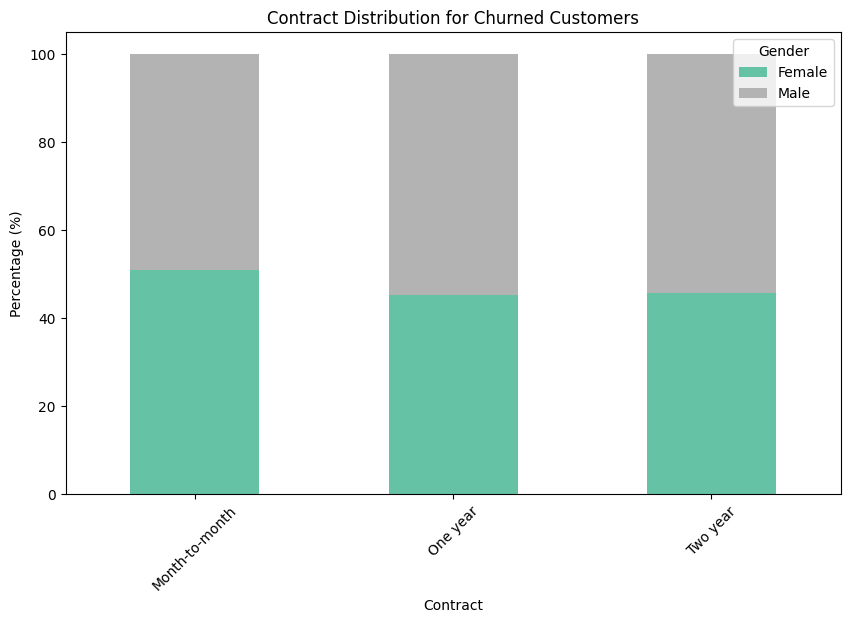

<Figure size 1000x600 with 0 Axes>

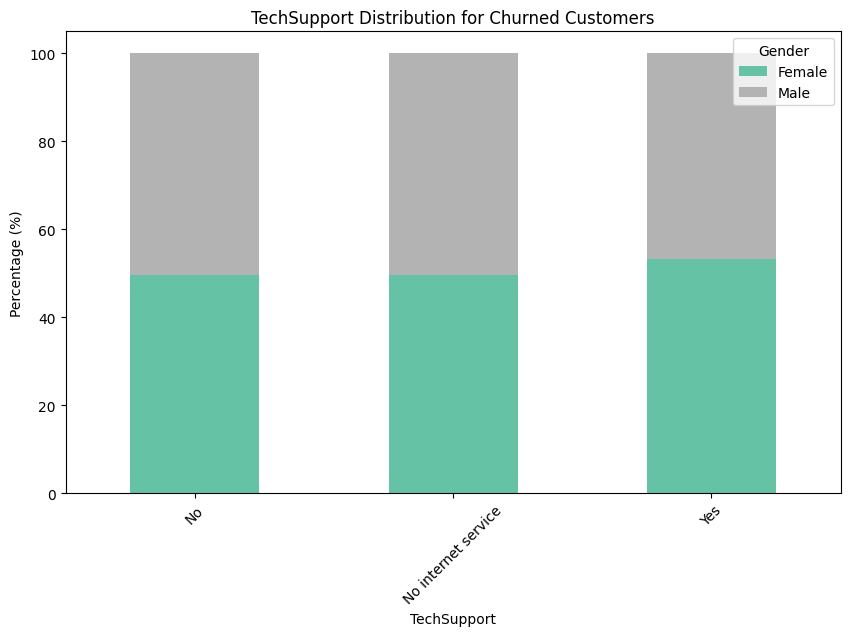

<Figure size 1000x600 with 0 Axes>

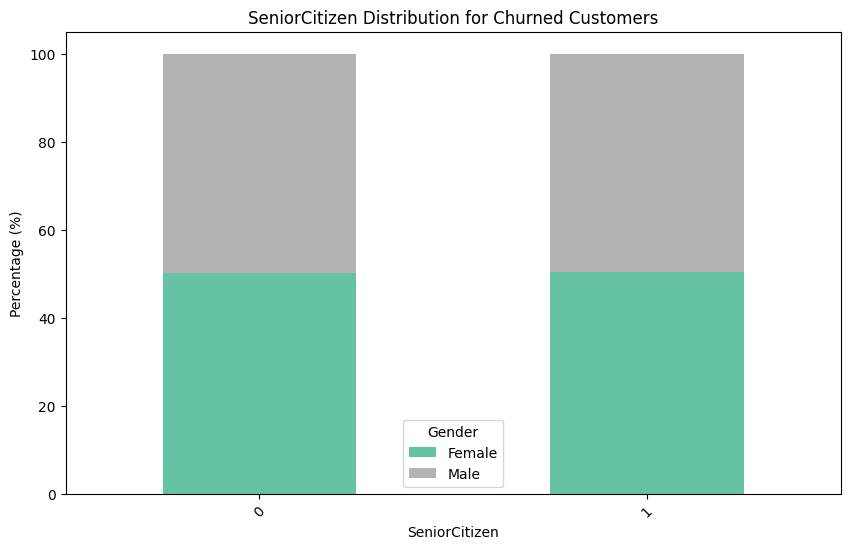

<Figure size 1000x600 with 0 Axes>

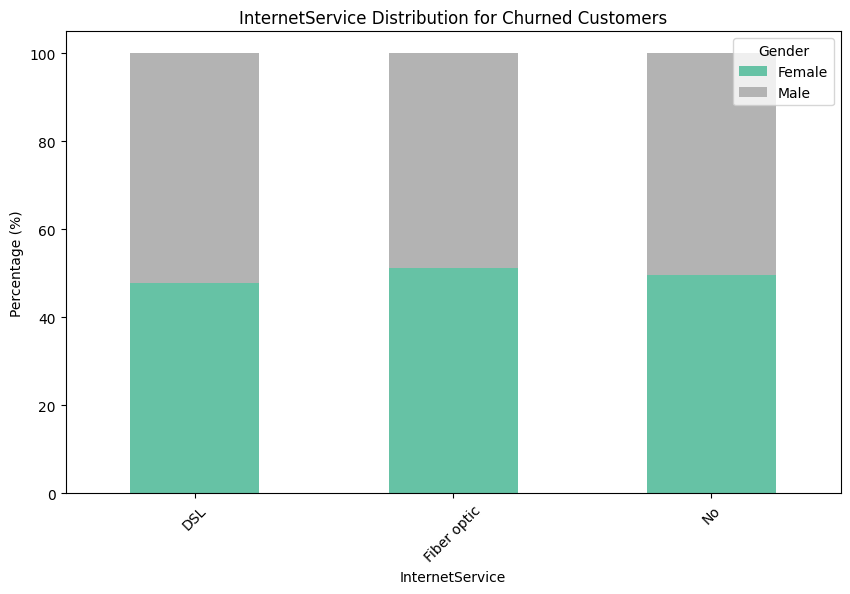

In [33]:
# Churned customers
churned = df_copy[df_copy['Churn'] == 1]

cols = [
    'Partner',
    'PaymentMethod',
    'Contract',
    'TechSupport',
    'SeniorCitizen',
    'InternetService'
]

for col in cols:

    plt.figure(figsize=(10, 6))

    percentage = pd.crosstab(
        churned[col],
        churned['gender'],
        normalize='index'
    ) * 100

    percentage.plot(
        kind='bar',
        stacked=True,
        figsize=(10,6),
        colormap='Set2'
    )

    plt.title(f'{col} Distribution for Churned Customers')
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Gender')

    plt.show()

## Insights from Bivariate Analysis

1. Electronic Check customers show the highest churn, making payment method an important churn indicator.
2. Month-to-month contracts have the highest churn, suggesting that customers without long-term commitments are more likely to leave.
3. Customers without Tech Support and Online Security churn more, highlighting the importance of value-added services in retention.
4. Gender has almost no impact on churn, as churn patterns are nearly identical for male and female customers.

Overall: Payment method, contract type, and support/security services are key drivers of churn, while demographic factors like gender contribute very little.

## Business Intelligence & Customer Risk Analysis

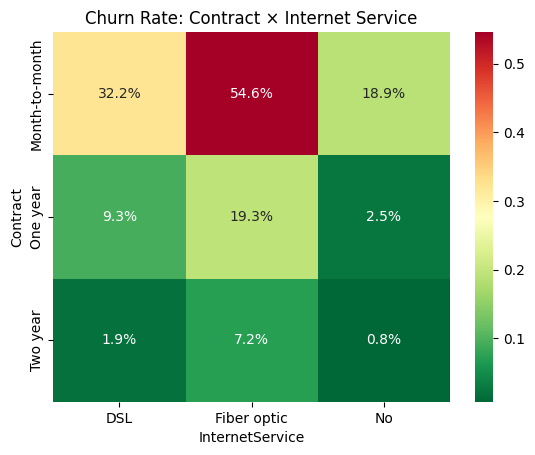

In [34]:
pivot = df_copy.groupby(['Contract', 'InternetService'])['Churn'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r')
plt.title('Churn Rate: Contract × Internet Service')
plt.show()

In [35]:
# High-Risk Customer Segment Analysis

high_risk = df_copy[
    (df_copy['Contract'] == 'Month-to-month') &
    (df_copy['InternetService'] == 'Fiber optic') &
    (df_copy['PaymentMethod'] == 'Electronic check') &
    (df_copy['tenure_group'] == '1 - 12')
]


print(f"Overall Churn Rate     : {df_copy['Churn'].mean():.1%}")
print(f"High-Risk Churn Rate   : {high_risk['Churn'].mean():.1%}")
print(f"Segment Size           : {len(high_risk)} customers ({len(high_risk)/len(df_copy):.1%} of total)")

print(f"\nIf a retention team can contact this segment first,")
print(f"they cover only {len(high_risk)/len(df_copy):.1%} of customers but target the highest-risk group.")

Overall Churn Rate     : 26.6%
High-Risk Churn Rate   : 71.2%
Segment Size           : 631 customers (9.0% of total)

If a retention team can contact this segment first,
they cover only 9.0% of customers but target the highest-risk group.


To identify customers who are most likely to churn, a high-risk segment was 
created using the key factors that showed the strongest relationship with churn during EDA.

High-Risk Criteria:
- Month-to-month contract
- Fiber optic internet service
- Electronic check payment method
- Tenure group: 1–12 months

The churn rate of this segment is then compared with the overall churn rate to 
evaluate how effectively these conditions identify high-risk customers.

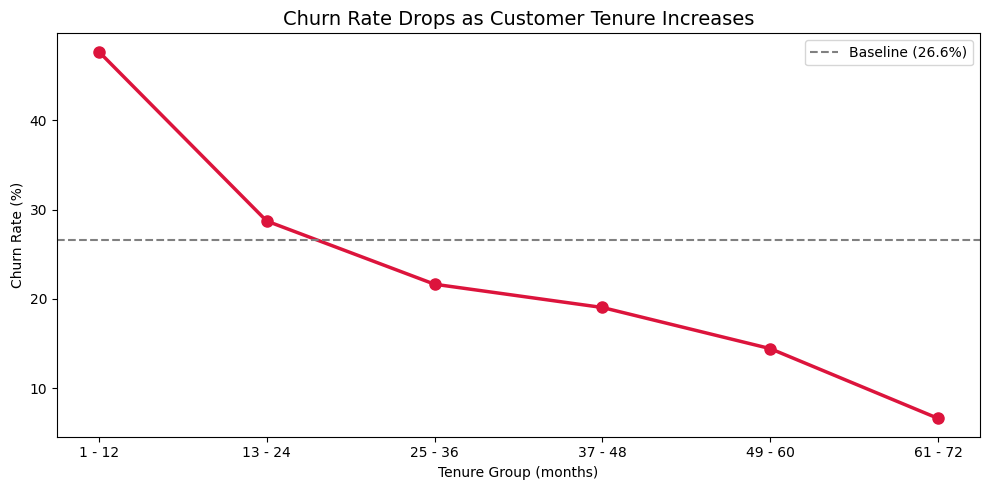

In [36]:
# Churn Rate by Tenure Group

tenure_churn = df_copy.groupby('tenure_group', observed=True)['Churn'].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(tenure_churn.index, tenure_churn.values, marker='o', 
         color='crimson', linewidth=2.5, markersize=8)

plt.axhline(y=df_copy['Churn'].mean() * 100, color='gray', 
            linestyle='--', label=f'Baseline ({df_copy["Churn"].mean()*100:.1f}%)')

plt.title('Churn Rate Drops as Customer Tenure Increases', fontsize=14)
plt.xlabel('Tenure Group (months)')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

The insight here is obvious the moment you see the chart — first year customers churn at nearly 2x the baseline, and by year 5-6 it's almost flat. This is called a survival curve and it tells the business: invest in the first 12 months or lose the customer forever.

In [37]:
# Revenue at Risk

churned = df_copy[df_copy['Churn'] == 1]
not_churned = df_copy[df_copy['Churn'] == 0]

monthly_revenue_lost = churned['MonthlyCharges'].sum()
avg_revenue_per_churner = churned['MonthlyCharges'].mean()
high_risk_revenue = high_risk[high_risk['Churn'] == 1]['MonthlyCharges'].sum()

print(f"Monthly revenue lost to churn         : ${monthly_revenue_lost:,.0f}")
print(f"Avg monthly charge of a churner       : ${avg_revenue_per_churner:.2f}")
print(f"Revenue at risk from high-risk segment: ${high_risk['MonthlyCharges'].sum():,.0f}/month")
print(f"\nIf we retain just 20% of churners, we save: ${monthly_revenue_lost * 0.20:,.0f}/month")

Monthly revenue lost to churn         : $139,131
Avg monthly charge of a churner       : $74.44
Revenue at risk from high-risk segment: $51,935/month

If we retain just 20% of churners, we save: $27,826/month


- Monthly Revenue Lost to Churn ($139,131): Total monthly revenue lost from customers who churned

- Average Monthly Charge of a Churner ($74.44): Average monthly amount paid by a customer before churning

- Revenue at Risk ($51,935/month): Monthly revenue generated by the identified high-risk customer segment


In [39]:
# Final dataset after EDA and cleaning
df_copy_dummies.to_csv('EDA_telco_churn.csv', index=False)

CONCLUSION:

* Electronic check medium are the highest churners
* Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.
* No Online security, No Tech Support category are high churners
* Non senior Citizens are high churners